In [1]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import torchvision.transforms as transforms
from collections import Counter
import numpy as np
import random
import warnings
import torch.nn as nn
import torch.optim as optim

In [2]:
pip install torch-lr-finder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-10.3.9.90:
      Successfully uninstalled nvidia-curand-cu12-10.3.9.90
  Attemptin

In [3]:
# set up python environment
seedVal = 123
random.seed(seedVal)
np.random.seed(seedVal)
torch.manual_seed(seedVal)
warnings.filterwarnings('ignore')

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(seedVal)
torch.cuda.manual_seed_all(seedVal)

In [4]:
def worker_init_fn(worker_id):
    seed = seedVal + worker_id
    np.random.seed(seed)
    random.seed(seed)

In [5]:
# define the transform to normalize, resize the images
transform = transforms.Compose([
    #Resizes the shortest side to 224 pixels.
    #This could potentialy make smaller images bigger and bigger images smaller.
    transforms.Resize(224), #If both sides are resized with the same length it could potentially distort the image.
    transforms.CenterCrop(224), ##Takes a sample of every image by cropping the center of the image and obtaining a 224x224 pixel image
    transforms.ToTensor(), #Convert images to tensor (To fit images into the model)
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) #Normalize images 
])

In [6]:
# load the predefine training data
trainingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train", transform = transform)
# load the predefine testing data
testingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test", transform = transform)

# define the size of the datasets, we already know the size
trainingSize = 100000
testingSize = 20000

testingProp = round((testingSize / (testingSize + trainingSize)) * 100)
print(testingProp)

validationSize = 20000
trainingSize = 80000

# check to see if the sizes match the total
trainingSize + validationSize + testingSize == 120000

# need to use the original length of training data to create the validation data
indices = list(range(100000)) #Creating a list of indices

random.shuffle(indices) #Shuffle dataset in respect to the seed value and avoid bias from the train dataset

# define the indices for training and validation data
trainIndices = indices[:trainingSize] #indices for train
validationIndices = indices[trainingSize:] #the rest of the indices for validation

# create the new training data and validation data
newTrainingData = Subset(trainingData, trainIndices) #80% of the dataset for training
validationData = Subset(trainingData, validationIndices) #20% of the dataset for validation


#Feed the model 32 samples at a time during training, feed dataset in original order, no need to shuffle again, use workers to maximize loading and efficientcy
train_loader = DataLoader(newTrainingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)

17


In [7]:
#Load pretrained EfficientNet-B0 model
efficientnet_model = models.efficientnet_b0(pretrained=True)

#Call for GPU (if available) for faster training, else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Freeze feature extractions from input data
for param in efficientnet_model.features.parameters():
    param.requires_grad = False #Preserve the pre-trained knowledge (Dont update weights during training)

#Define the number of classes (2)
efficientnet_model.classifier[1] = nn.Linear(efficientnet_model.classifier[1].in_features, 2)
efficientnet_model = efficientnet_model.to(device) # Run model on GPU or CPU

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 109MB/s] 


  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 8.90E-03


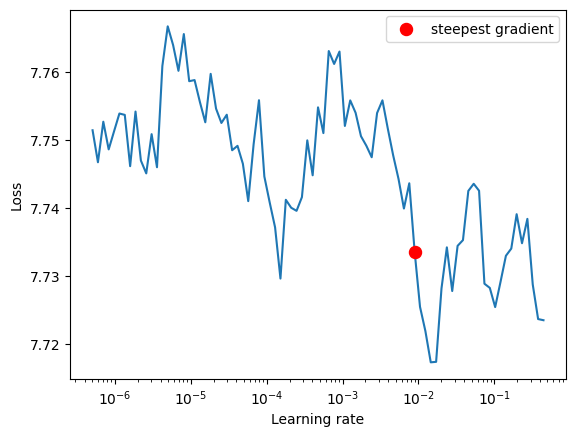

In [8]:
from torch_lr_finder import LRFinder

# Model, criterion, optimizer setup
model = models.efficientnet_b0(pretrained=True)
criterion = torch.nn.CrossEntropyLoss()  # CrossEntropyLoss for logits
optimizer = optim.SGD(efficientnet_model.parameters(), lr=1e-7)  # start with very small lr

# Wrap with lr finder
lr_finder = LRFinder(model, optimizer, criterion, device="cpu")
lr_finder.range_test(train_loader, end_lr=1, num_iter=100)  # adjust num_iter if needed
lr_finder.plot()  # plot loss vs learning rate
lr_finder.reset()
